### Introduction About the Data :

**The dataset** The goal is to predict `price` of given diamond (Regression Analysis).

There are 10 independent variables (including `id`):

* `id` : unique identifier of each diamond
* `carat` : Carat (ct.) refers to the unique unit of weight measurement used exclusively to weigh gemstones and diamonds.
* `cut` : Quality of Diamond Cut
* `color` : Color of Diamond
* `clarity` : Diamond clarity is a measure of the purity and rarity of the stone, graded by the visibility of these characteristics under 10-power magnification.
* `depth` : The depth of diamond is its height (in millimeters) measured from the culet (bottom tip) to the table (flat, top surface)
* `table` : A diamond's table is the facet which can be seen when the stone is viewed face up.
* `x` : Diamond X dimension
* `y` : Diamond Y dimension
* `x` : Diamond Z dimension

Target variable:
* `price`: Price of the given Diamond.

Dataset Source Link :
[https://www.kaggle.com/competitions/playground-series-s3e8/data?select=train.csv](https://www.kaggle.com/competitions/playground-series-s3e8/data?select=train.csv)

In [1]:
### Importing libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r'R:\HuB\ESPERANTO\Data_Science\MachineLearningEndToEndProject\RegressionModel\DiamondPricePrediction\notebook\data\gemstone.csv')
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [5]:
## Checking Null values 
df[df.isnull()].sum()

id         0.0
carat      0.0
cut          0
color        0
clarity      0
depth      0.0
table      0.0
x          0.0
y          0.0
z          0.0
price      0.0
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  object 
 3   color    193573 non-null  object 
 4   clarity  193573 non-null  object 
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 16.2+ MB


In [7]:
df1 = df.drop('id',axis=1)

In [8]:
df1[df1.duplicated()].sum()

carat      0.0
cut          0
color        0
clarity      0
depth      0.0
table      0.0
x          0.0
y          0.0
z          0.0
price        0
dtype: object

In [10]:
cat_cols = df1.columns[df1.dtypes == 'object']
num_cols = df1.columns[df1.dtypes != 'object']

In [11]:
df1[cat_cols].describe()

,cut,color,clarity
count,193573,193573,193573
unique,5,7,8
top,Ideal,G,SI1
freq,92454,44391,53272


In [12]:
df1[num_cols].describe()

,carat,depth,table,x,y,z,price
count,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000
mean,0.790688,61.820574,57.227675,5.715312,5.720094,3.534246,3969.155414
std,0.462688,1.081704,1.918844,1.109422,1.102333,0.688922,4034.374138
min,0.200000,52.100000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.300000,56.000000,4.700000,4.710000,2.900000,951.000000
50%,0.700000,61.900000,57.000000,5.700000,5.720000,3.530000,2401.000000
75%,1.030000,62.400000,58.000000,6.510000,6.510000,4.030000,5408.000000
max,3.500000,71.600000,79.000000,9.650000,10.010000,31.300000,18818.000000


In [13]:
cat_cols

Index(['cut', 'color', 'clarity'], dtype='object')

In [14]:
df1['cut'].value_counts()

cut
Ideal        92454
Premium      49910
Very Good    37566
Good         11622
Fair          2021
Name: count, dtype: int64

In [15]:
df1['color'].value_counts()

color
G    44391
E    35869
F    34258
H    30799
D    24286
I    17514
J     6456
Name: count, dtype: int64

In [16]:
df1['clarity'].value_counts()

clarity
SI1     53272
VS2     48027
VS1     30669
SI2     30484
VVS2    15762
VVS1    10628
IF       4219
I1        512
Name: count, dtype: int64

<Axes: >

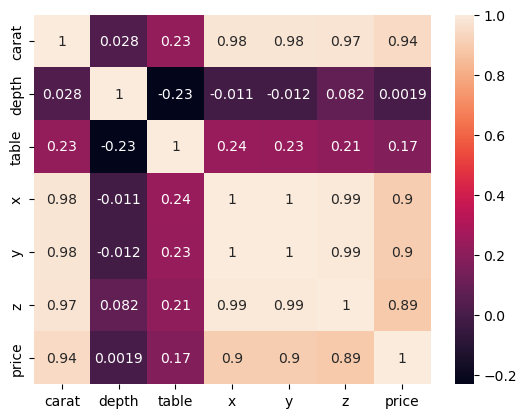

In [20]:
sns.heatmap(df1[num_cols].corr(),annot=True)

In [21]:
df_num = df1[num_cols].drop(labels=['x','y','z'],axis=1)

In [22]:
df_num

,carat,depth,table,price
0,1.52,62.2,58.0,13619
1,2.03,62.0,58.0,13387
2,0.70,61.2,57.0,2772
3,0.32,61.6,56.0,666
4,1.70,62.6,59.0,14453
...,...,...,...,...
193568,0.31,61.1,56.0,1130
193569,0.70,60.3,58.0,2874
193570,0.73,63.1,57.0,3036
193571,0.34,62.9,55.0,681


<Axes: >

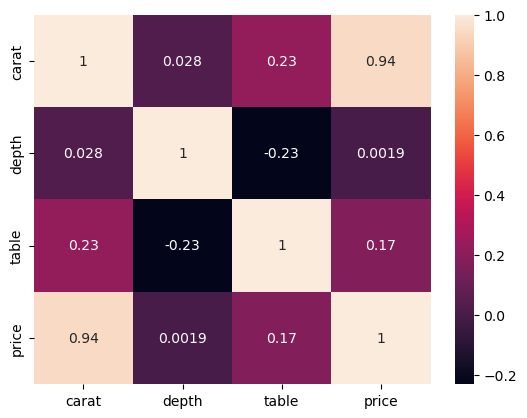

In [23]:
sns.heatmap(df_num.corr(),annot=True)

In [29]:
cut_map = {'Ideal':1,'Premium':2,'Very Good':3,'Good':4,'Fair':5}
color_map = {'D':7,'E':6,'F':5,'G':4,'H':3 ,'I':2,'J':1}
clarity_map = {'I1':8, 'SI2':7, 'SI1':6, 'VS2':5, 'VS1':4, 'VVS2':3, 'VVS1':2, 'IF':1}

In [27]:
df_cat = df1[cat_cols]

In [30]:
df_cat['color'] = df_cat['color'].map(color_map)
df_cat['cut'] = df_cat['cut'].map(cut_map)
df_cat['clarity'] = df_cat['clarity'].map(clarity_map)

In [37]:
df_cat.info()
df_cat.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   cut      193573 non-null  int64
 1   color    193573 non-null  int64
 2   clarity  193573 non-null  int64
dtypes: int64(3)
memory usage: 4.4 MB


(193573, 3)

In [34]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   carat   193573 non-null  float64
 1   depth   193573 non-null  float64
 2   table   193573 non-null  float64
 3   price   193573 non-null  int64  
dtypes: float64(3), int64(1)
memory usage: 5.9 MB


In [44]:
for i in df_num.columns:
    print(i)

carat
depth
table
price


In [49]:
df_final = df = pd.concat([df_num, df_cat], axis=1)

In [50]:
df_final.head()

,carat,depth,table,price,cut,color,clarity
0,1.52,62.2,58.0,13619,2,5,5
1,2.03,62.0,58.0,13387,3,1,7
2,0.70,61.2,57.0,2772,1,4,4
3,0.32,61.6,56.0,666,1,4,4
4,1.70,62.6,59.0,14453,2,4,5


In [51]:
# Save processed dataframe to CSV in notebook/data
output_path = r'R:\HuB\ESPERANTO\Data_Science\MachineLearningEndToEndProject\RegressionModel\DiamondPricePrediction\notebook\data\gemstone_processed.csv'
# If df_final is defined in the notebook, this will write it out.
df_final.to_csv(output_path, index=False)
print(f"Saved processed CSV to: {output_path}")

Saved processed CSV to: R:\HuB\ESPERANTO\Data_Science\MachineLearningEndToEndProject\RegressionModel\DiamondPricePrediction\notebook\data\gemstone_processed.csv
